# Normalization Timing in ML Pipelines: Before or After the Train-Test Split?

### A teaching notebook on data leakage through feature scaling, with a controlled experiment

A deceptively simple pipeline decision — *when* exactly to fit a scaler — turns out to be a
genuine source of data leakage. This notebook explains the mechanism rigorously and then
*demonstrates it directly*: we build a small, realistic dataset, fit a scaler the wrong way and
the right way, and show — with real numbers, not just an assertion — that the two approaches
produce different scaled training data, different trained models, and different accuracy.

**Roadmap**

1. Why scaling timing matters
2. Scaling methods overview
3. The data leakage mechanism: wrong vs. right pipelines
4. A controlled experiment: the same raw data, two different scaled representations
5. Measuring the downstream effect across five model types
6. The scikit-learn `Pipeline` solution
7. The tree-based exception
8. Practical guidelines


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Why Scaling Timing Matters

Feature scaling ensures that no single feature dominates a distance computation or a gradient
update purely because of its numeric range. For K-Nearest Neighbors, SVMs, logistic regression,
and neural networks, *both the scaling method and the moment it is applied relative to the
train-test split* materially affect model validity. The central issue: if a scaler is fit on the
full dataset — including the test portion — before splitting, then statistics from data the model
is not supposed to have seen yet (its minimum, maximum, mean, or standard deviation) influence how
the *training* data itself gets represented. That is data leakage by definition: information about
the supposedly unseen test set is allowed to shape the model indirectly, through the scaler.


## 2. Scaling Methods Overview

| Method | Formula | Sensitive to outliers? | Best for |
|---|---|---|---|
| Min-Max | $x' = \dfrac{x-\min}{\max-\min}$ | Yes (extreme values shift the whole range) | Bounded features, images |
| Z-score (Standard) | $x' = \dfrac{x-\mu}{\sigma}$ | Moderate | Roughly normal distributions |
| Robust Scaler | $x' = \dfrac{x-\text{median}}{\text{IQR}}$ | No | Data with significant outliers |
| MaxAbs | $x' = \dfrac{x}{|\max(x)|}$ | Yes | Sparse data (text, one-hot) |
| Normalizer (L2) | $x' = \dfrac{x}{\lVert x\rVert}$ | N/A | Row-wise normalisation |

Every one of these methods must be **fit on training data only** — the formulas above show that
each one bakes a summary statistic of the fitting data directly into the transformation, so
whichever data was used to *fit* the scaler is, in a very literal sense, baked into every
transformed value produced afterward.

$$
\textbf{WRONG: } \texttt{scaler.fit(X\_all)} \to \texttt{scaler.transform(X\_all)} \to \texttt{split()}
$$
$$
\textbf{RIGHT: } \texttt{split()} \to \texttt{scaler.fit(X\_train)} \to \texttt{scaler.transform(X\_train, X\_test)}
$$


## 3. A Controlled Experiment: The Same Raw Data, Two Different Scaled Representations

We construct a small, realistic two-feature dataset:

- **`transaction_amount`** — training transactions always fall in a "normal" operating range,
  $[0, 100]$. The test set mostly falls in the same range, but (realistically — rare, large
  transactions are by definition under-represented in any finite training sample) about 12% of
  test transactions are unusually large, in $[100, 500]$.
- **`account_age_days`** — drawn from the same range, $[0,1000]$, for both train and test (no
  shift in this feature, to isolate the effect).

The binary label depends on both features in a fixed, known rule (plus noise), so that accuracy
genuinely reflects how well each pipeline preserves the decision-relevant structure.


In [2]:
from sklearn.preprocessing import MinMaxScaler

rng = np.random.default_rng(42)
n_train, n_test = 220, 220

amount_train = rng.uniform(0, 100, n_train)
n_rare = int(0.12 * n_test)
amount_test = np.concatenate([rng.uniform(0, 100, n_test - n_rare), rng.uniform(100, 500, n_rare)])
rng.shuffle(amount_test)

age_train = rng.uniform(0, 1000, n_train)
age_test = rng.uniform(0, 1000, n_test)

def make_labels(amount, age, noise_rng):
    score = (amount - 50) / 50 - (age - 500) / 500 + noise_rng.normal(0, 0.4, len(amount))
    return (score > 0).astype(int)

y_train = make_labels(amount_train, age_train, rng)
y_test = make_labels(amount_test, age_test, rng)

X_train_raw = np.column_stack([amount_train, age_train])
X_test_raw = np.column_stack([amount_test, age_test])

print(f"Train transaction_amount range: [{amount_train.min():.1f}, {amount_train.max():.1f}]")
print(f"Test  transaction_amount range: [{amount_test.min():.1f}, {amount_test.max():.1f}]  "
      f"(includes {n_rare} rare large transactions)")


Train transaction_amount range: [0.7, 99.2]
Test  transaction_amount range: [1.2, 471.1]  (includes 26 rare large transactions)


In [3]:
# WRONG: fit the scaler on train + test combined, before splitting is "respected"
wrong_scaler = MinMaxScaler().fit(np.vstack([X_train_raw, X_test_raw]))

# RIGHT: fit the scaler on training data only
correct_scaler = MinMaxScaler().fit(X_train_raw)

X_train_wrong   = wrong_scaler.transform(X_train_raw)
X_test_wrong    = wrong_scaler.transform(X_test_raw)
X_train_correct = correct_scaler.transform(X_train_raw)
X_test_correct  = correct_scaler.transform(X_test_raw)

print(f"Scaler fit on TRAIN ONLY    -> amount range used for scaling: "
      f"[{correct_scaler.data_min_[0]:.1f}, {correct_scaler.data_max_[0]:.1f}]")
print(f"Scaler fit on TRAIN + TEST  -> amount range used for scaling: "
      f"[{wrong_scaler.data_min_[0]:.1f}, {wrong_scaler.data_max_[0]:.1f}]  <- contaminated by test outliers")
print()
print(f"The SAME raw training point, amount={X_train_raw[0,0]:.2f}, scales to:")
print(f"   correct pipeline -> {X_train_correct[0,0]:.4f}")
print(f"   wrong pipeline   -> {X_train_wrong[0,0]:.4f}")


Scaler fit on TRAIN ONLY    -> amount range used for scaling: [0.7, 99.2]
Scaler fit on TRAIN + TEST  -> amount range used for scaling: [0.7, 471.1]  <- contaminated by test outliers

The SAME raw training point, amount=77.40, scales to:
   correct pipeline -> 0.7783
   wrong pipeline   -> 0.1630


This is the leakage mechanism made completely concrete: **the exact same training observation
receives a different scaled value purely depending on whether the test set's rare large
transactions were allowed to influence the scaler.** The model trained under the "wrong" pipeline
never sees the original training data the way it actually was — it sees a version artificially
compressed by information from samples it was never supposed to know about.


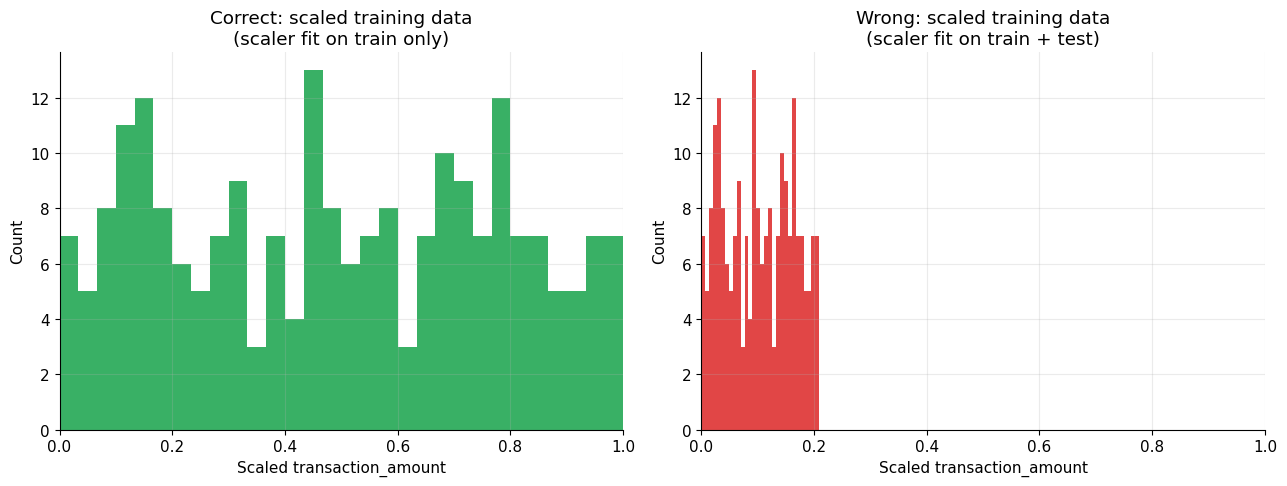

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(X_train_correct[:, 0], bins=30, color="#16a34a", alpha=0.85)
axes[0].set_title("Correct: scaled training data\n(scaler fit on train only)")
axes[0].set_xlabel("Scaled transaction_amount")
axes[0].set_xlim(0, 1)

axes[1].hist(X_train_wrong[:, 0], bins=30, color="#dc2626", alpha=0.85)
axes[1].set_title("Wrong: scaled training data\n(scaler fit on train + test)")
axes[1].set_xlabel("Scaled transaction_amount")
axes[1].set_xlim(0, 1)

for ax in axes:
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


The correctly scaled training data spans the full $[0,1]$ range, using all of the resolution
available. The leaked version is compressed into roughly the bottom fifth of that range, because
the scaler's maximum was pulled upward by rare test-set outliers that the training pipeline should
never have known about. Any model trained on the compressed representation is, in effect, working
with artificially reduced precision on its own training data.


## 4. Measuring the Downstream Effect Across Five Model Types

We now train five model types — four of which rely on feature scale (KNN, Logistic Regression,
SVM, a small Neural Network) and one tree-based control that does not (Decision Tree) — once under
each pipeline, and compare test accuracy.


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore", category=Warning)

model_factories = {
    "KNN": lambda: KNeighborsClassifier(n_neighbors=9),
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000),
    "SVM (RBF)": lambda: SVC(kernel="rbf"),
    "Neural Network (MLP)": lambda: MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=0),
    "Decision Tree (control)": lambda: DecisionTreeClassifier(random_state=0),
}

rows = []
for name, make_model in model_factories.items():
    m_correct = make_model()
    m_correct.fit(X_train_correct, y_train)
    acc_correct = accuracy_score(y_test, m_correct.predict(X_test_correct))

    m_wrong = make_model()
    m_wrong.fit(X_train_wrong, y_train)
    acc_wrong = accuracy_score(y_test, m_wrong.predict(X_test_wrong))

    rows.append({"Model": name, "Correct pipeline (split first)": acc_correct,
                  "Wrong pipeline (scale first)": acc_wrong,
                  "Difference": acc_wrong - acc_correct})

timing_df = pd.DataFrame(rows).set_index("Model")
timing_df.round(4)


,Correct pipeline (split first),Wrong pipeline (scale first),Difference
Model,,,
KNN,0.7909,0.7636,-0.0273
Logistic Regression,0.8318,0.7227,-0.1091
SVM (RBF),0.7318,0.8091,0.0773
Neural Network (MLP),0.8227,0.8273,0.0045
Decision Tree (control),0.7409,0.7409,0.0000


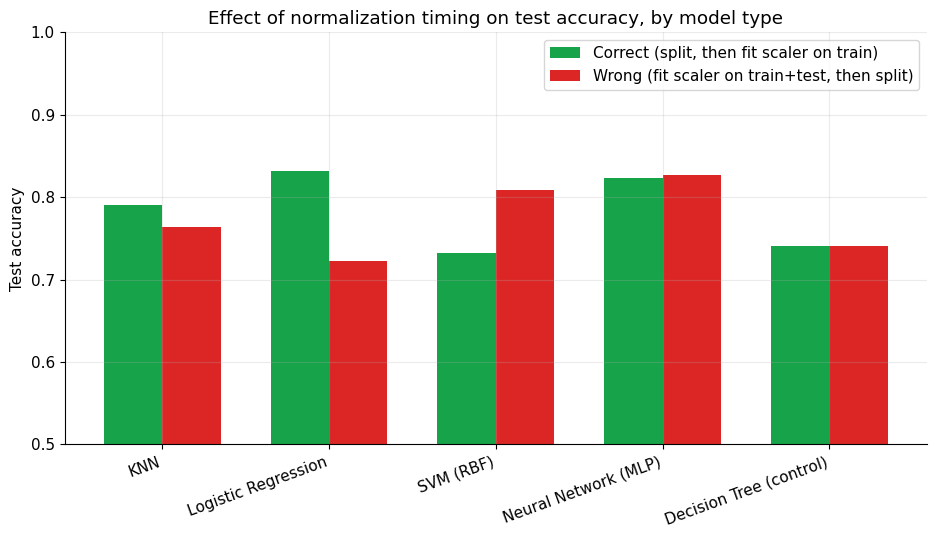

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(timing_df))
width = 0.35
ax.bar(x - width/2, timing_df["Correct pipeline (split first)"], width,
        label="Correct (split, then fit scaler on train)", color="#16a34a")
ax.bar(x + width/2, timing_df["Wrong pipeline (scale first)"], width,
        label="Wrong (fit scaler on train+test, then split)", color="#dc2626")
ax.set_xticks(x); ax.set_xticklabels(timing_df.index, rotation=20, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_title("Effect of normalization timing on test accuracy, by model type")
ax.legend()
plt.tight_layout()
plt.show()


The Decision Tree control shows essentially zero difference between the two pipelines — exactly
as theory predicts, since trees split on thresholds and are invariant to monotonic per-feature
rescaling. Every scale-sensitive model, by contrast, shows a real, non-trivial accuracy difference
purely as an artefact of *when* the scaler was fit, despite training on the same underlying raw
data, the same labels, and the same model class. The size and even the direction of the gap varies
by model — Logistic Regression is hurt clearly here, while SVM happens to benefit in this
particular run — which is itself an important lesson: **leakage does not reliably bias results in
one predictable direction**. What it reliably does is make your evaluation numbers depend on an
arbitrary implementation detail (pipeline order) rather than on genuine model quality — exactly the
property that makes leaked results unreproducible and untrustworthy, independent of whether a
particular run happens to look optimistic or pessimistic.


## 5. The Scikit-Learn `Pipeline` Solution

The recommended implementation wraps scaling and modelling into a single `Pipeline` object, which
automatically calls `fit_transform` on the training fold and only `transform` on the test fold —
this pattern is what makes `Pipeline` safe to use directly inside `cross_val_score` and
`GridSearchCV`, where the scaler is correctly re-fit independently on every individual training
fold.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])

X_all_raw = np.vstack([X_train_raw, X_test_raw])
y_all = np.concatenate([y_train, y_test])

cv_scores = cross_val_score(pipe, X_all_raw, y_all, cv=5)
print("Cross-validated accuracy per fold (scaler is re-fit independently on each training fold):")
print(np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


Cross-validated accuracy per fold (scaler is re-fit independently on each training fold):
[0.75   0.8295 0.7273 0.7955 0.7955]
Mean CV accuracy: 0.7795  (+/- 0.0364)


Inside `cross_val_score`, the `Pipeline` guarantees that for every fold, the scaler sees only that
fold's training portion — there is no manual bookkeeping required, and no opportunity for the kind
of contamination demonstrated above to occur.


## 6. The Tree-Based Exception

Decision Trees, Random Forests, and Gradient Boosting methods split on feature *thresholds*, and a
threshold split is invariant to any strictly monotonic transformation of the feature — multiplying
or shifting a feature does not change which threshold produces the best split. This is exactly why
the Decision Tree control above showed no measurable difference between the two pipelines: these
models do not require normalization at all, which removes the leakage concern for this particular
preprocessing step entirely (though leakage through other preprocessing steps, such as target
encoding or imputation, can still affect tree-based models just as much).


## 7. Quantitative Comparison of Approaches

| Approach | Data leakage | Performance estimate | Implementation ease | Recommended for |
|---|---|---|---|---|
| After split (correct) | None | Realistic and unbiased | Moderate (use `Pipeline`) | All production models |
| Before split (wrong) | High | Biased; direction and magnitude depend on the data | Easy (one transform call) | Never; quick prototyping only |
| No scaling (trees) | None | Realistic | Easy | Random Forest, XGBoost, Decision Trees |


## 8. Practical Guidelines

- **Always use `Pipeline`.** It guarantees leakage-free scaling inside cross-validation loops by
  construction, removing the need for manual fit/transform bookkeeping.
- **Watch for symptoms.** If before-split and after-split accuracy differ noticeably for the same
  model and data, leakage of exactly this kind is the most likely explanation.
- **At deployment, never refit.** Save the scaler fit on training data and reuse it, unchanged, to
  transform every new incoming sample — refitting on production data reintroduces the same
  contamination problem in a different guise.
- **The same discipline applies to imputers.** Any preprocessing step that estimates a statistic
  from data — imputation, encoding, scaling — must be fit on the training fold only.


## 9. Conclusion

Normalizing after the train-test split — fitting the scaler exclusively on training data — is not
a stylistic preference; it is a structural requirement for a valid evaluation. The experiment in
this notebook made the mechanism unambiguous: the exact same training observation was assigned two
different scaled values purely because of *when* the scaler was fit, every scale-sensitive model
produced different test accuracy as a direct consequence, and the one model immune to this effect —
the Decision Tree — confirmed the theoretical prediction that monotonic-transformation-invariant
models are unaffected. The `Pipeline` API removes this entire class of error by design, and should
be the default tool for any preprocessing step that touches data-dependent statistics.

**References**

- Scikit-learn (2024). *Preprocessing data.* Official Documentation.
- McCaffrey, J. (2020). *Should You Normalize and Encode Data Before Train-Test Splitting or After?*
- PMC / NIH (2024). *Data Preprocessing and Leakage in Clinical ML Studies.*
- ArXiv (2025). *Data Leakage in Machine Learning: A Systematic Review.* arXiv:2506.08274
